In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Load clean data from Delta table
df = spark.read.table("workspace.default.telco_churn_clean")
df_model = df.toPandas()

print(f"Shape: {df_model.shape}")
print("Data loaded successfully!")

Shape: (7017, 20)
Data loaded successfully!


In [0]:
# Convert target column Churn to 1/0
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Convert all other categorical columns to numbers
df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape after encoding: ", df_model.shape)
print("Columns after encoding:")
print(df_model.columns.tolist())


Shape after encoding:  (7017, 31)
Columns after encoding:
['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [0]:
#Define X and y

y = df_model['Churn']
X = df_model.drop('Churn', axis=1)

print("X shape: ", X.shape)
print("y shape: ",y.shape)
print("Churn distribution:")
print(y.value_counts())

X shape:  (7017, 30)
y shape:  (7017,)
Churn distribution:
Churn
0    5163
1    1854
Name: count, dtype: int64


In [0]:
# Train test split
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size = 0.2, random_state = 1)

print("Training set: ", train_X.shape)
print("Validation set: ", val_X.shape)

# Random Forest Classifier

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(train_X, train_y)

print(" Model trained successfully!")

Training set:  (5613, 30)
Validation set:  (1404, 30)
 Model trained successfully!


Accuracy:  77.42
Classification Report: 
              precision    recall  f1-score   support

 Not Churned       0.83      0.87      0.85      1031
     Churned       0.59      0.50      0.54       373

    accuracy                           0.77      1404
   macro avg       0.71      0.69      0.70      1404
weighted avg       0.76      0.77      0.77      1404



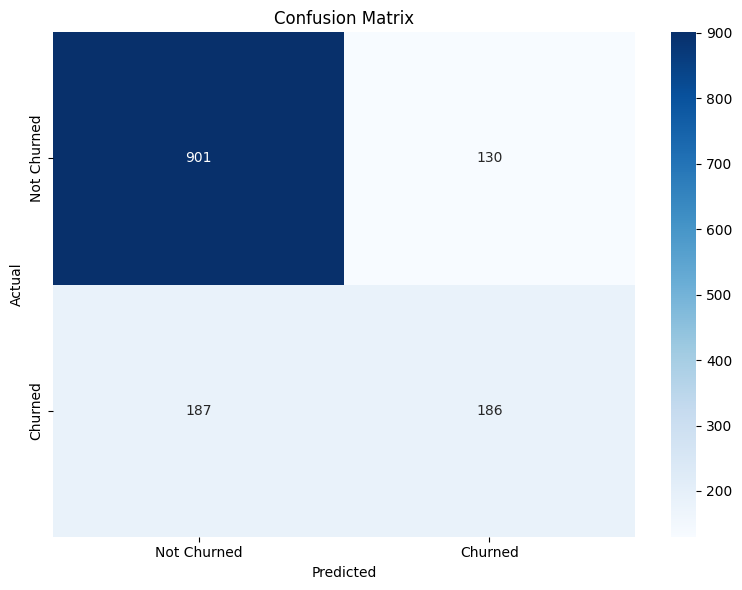

In [0]:
# Evaluate the model

predictions = model.predict(val_X)

# Accuracy score
accuracy = accuracy_score(val_y, predictions)
print("Accuracy: ", round(accuracy * 100, 2))

# Classification report

print("Classification Report: ")
print(classification_report(val_y, predictions, target_names=['Not Churned', 'Churned']))

# Confusion matrix
cm = confusion_matrix(val_y, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

/home/spark-e9ccede8-98e9-4876-b24e-4b/.ipykernel/2030/command-7934793470806369-144928205:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='Blues_r')


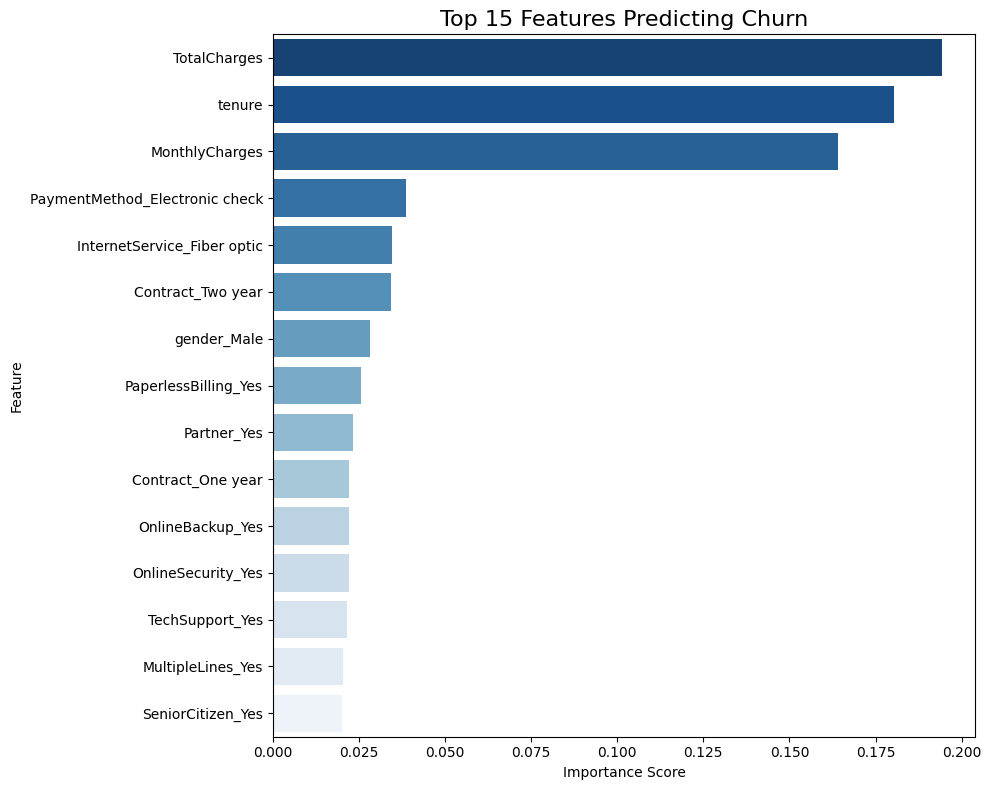

                           feature  importance
2                     TotalCharges    0.194274
0                           tenure    0.180366
1                   MonthlyCharges    0.164205
28  PaymentMethod_Electronic check    0.038539
10     InternetService_Fiber optic    0.034478
25               Contract_Two year    0.034460
3                      gender_Male    0.028230
26            PaperlessBilling_Yes    0.025560
5                      Partner_Yes    0.023187
24               Contract_One year    0.022231
15                OnlineBackup_Yes    0.022179
13              OnlineSecurity_Yes    0.022091
19                 TechSupport_Yes    0.021630
9                MultipleLines_Yes    0.020419
4                SeniorCitizen_Yes    0.020032


In [0]:
# Feature Importance

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='Blues_r')
plt.title('Top 15 Features Predicting Churn', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance)

In [0]:
# Add churn risk scores back to original dataframe
df_model['churn_probability'] = model.predict_proba(X)[:, 1]
df_model['churn_prediction'] = model.predict(X)

# High risk customers
high_risk = df_model[df_model['churn_probability'] >= 0.7].shape[0]
medium_risk = df_model[(df_model['churn_probability'] >= 0.4) & 
                        (df_model['churn_probability'] < 0.7)].shape[0]
low_risk = df_model[df_model['churn_probability'] < 0.4].shape[0]

print(f"High Risk customers (70%+ churn probability): {high_risk}")
print(f"Medium Risk customers (40-70% churn probability): {medium_risk}")
print(f"Low Risk customers (under 40% churn probability): {low_risk}")

High Risk customers (70%+ churn probability): 1406
Medium Risk customers (40-70% churn probability): 529
Low Risk customers (under 40% churn probability): 5082


In [0]:
df_model_export = spark.createDataFrame(df_model)
df_model_export.write.mode("overwrite").csv(
    "/Volumes/workspace/default/churn_data/telco_churn_final",
    header=True
)
print("File saved to volume!")

File saved to volume!


In [0]:
df_model.to_csv(
    '/Volumes/workspace/default/churn_data/telco_churn_final.csv',
    index=False
)
print("Single CSV saved!")

Single CSV saved!


In [0]:
# Convert all boolean columns to integers (1/0)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)


df_model.to_csv(
    '/Volumes/workspace/default/churn_data/telco_churn_final.csv',
    index=False
)
print("Fixed CSV saved!")
print(df_model.dtypes)

Fixed CSV saved!
tenure                                     int32
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
SeniorCitizen_Yes                          int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
Tec

In [0]:
# Data suitable for tableau
df_tableau = spark.read.table("workspace.default.telco_churn_clean").toPandas()

df_tableau.to_csv(
    '/Volumes/workspace/default/churn_data/telco_churn_tableau.csv',
    index=False
)
print("Tableau CSV saved!")
print(df_tableau.shape)

Tableau CSV saved!
(7017, 20)
